# Private-deliberation information-boundary decomposition

This notebook directly varies the observer information boundary while holding the consequential action and post-deliberation activation fixed. It separates an information-asymmetric activation advantage from the matched-information privilege test.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Private-deliberation information decomposition

## Separating early prediction, newly private deliberation, and matched-text exposure

A standard autoregressive language model cannot perform additional "silent thinking" that changes its hidden state without processing additional tokens. This notebook therefore tests the strongest clean decomposition available without modifying the model architecture.

For each of the same 40 frozen Diplomacy source games:

1. **Pre-deliberation (T0):** capture the subject activation immediately before it generates private deliberation. A text observer sees exactly this pre-deliberation information and predicts the subject's *later* final order.
2. **Private-deliberation (T1-private):** the subject generates a private strategic deliberation, receives that exact text in its final action prompt, and we capture the post-deliberation activation. The pre-deliberation observer remains blind to the generated deliberation. This comparison is intentionally information-asymmetric and measures the predictive value of newly created private deliberation.
3. **Exposed-deliberation (T1-matched):** a second text observer receives the **identical final prompt including the frozen deliberation**. The neural activation and consequential action are unchanged. This restores the matched-information contract.

### Key diagnostic pattern
If post-deliberation activations beat the stale pre-deliberation observer but do **not** beat the exposed-deliberation observer, while exposing deliberation strongly improves text prediction, then an apparent post-deliberation neural advantage is explained by information asymmetry rather than uniquely neural access.


In [1]:
NOTEBOOK_BUILD="latent-reservations-p3-private-deliberation-information-decomposition-v1"
print("="*104); print(NOTEBOOK_BUILD); print("="*104)


latent-reservations-p3-private-deliberation-information-decomposition-v1


## 1. Dependencies and frozen 40-game source bank


In [2]:
from __future__ import annotations
import gc,hashlib,json,os,re,subprocess,sys,zipfile
from datetime import datetime,timezone
from pathlib import Path
subprocess.run([sys.executable,"-m","pip","install","numpy<2","pandas>=2,<3","scikit-learn>=1.4,<2","scipy>=1.12,<2","safetensors>=0.4","transformers>=4.45,<5","accelerate>=0.30,<2","tqdm>=4.66","matplotlib>=3.8,<4"],check=True)
import numpy as np,pandas as pd
from tqdm.auto import tqdm
PROJECT_ROOT=Path(os.environ.get("LR_PROJECT_ROOT","/workspace/latent-reservations")).expanduser().resolve(); CICERO_REPO=PROJECT_ROOT/"vendor/diplomacy_cicero"; HF_CACHE_DIR=Path(os.environ.get("LR_HF_CACHE_DIR",os.environ.get("HF_HOME","/workspace/.cache/huggingface"))).expanduser().resolve()
SOURCE_RUN_ID=os.environ.get("LR_P3_SOURCE_NB13_RUN_ID","20260814T205212Z"); SOURCE_RUN_DIR=Path(os.environ.get("LR_P3_SOURCE_NB13_RUN_DIR",str(PROJECT_ROOT/"notebook_outputs"/"13_qwen_format_activation_timing_ablation"/SOURCE_RUN_ID))).expanduser().resolve(); EXPECTED_BANK_SHA="d29ad1d616fae9c8f6ddf04983fba6421249c544afc767ea33be1d746e21b389"
bank_path=SOURCE_RUN_DIR/"results/tables/source_state_bank_preoutcome.csv"
if not bank_path.exists(): raise FileNotFoundError(bank_path)
if hashlib.sha256(bank_path.read_bytes()).hexdigest()!=EXPECTED_BANK_SHA: raise RuntimeError("Frozen P3 source bank hash mismatch")
state_bank_df=pd.read_csv(bank_path); state_dir=SOURCE_RUN_DIR/"data/states"; selected_states=[]
for sid in state_bank_df.state_id.astype(str):
    p=state_dir/f"{sid}.json"
    if not p.exists(): raise FileNotFoundError(p)
    selected_states.append(json.loads(p.read_text()))
if len(selected_states)!=40 or state_bank_df.game_index.nunique()!=40: raise RuntimeError("P3 requires exactly one frozen state from each of 40 source games")
NOTEBOOK_SLUG="22_private_deliberation_information_decomposition"; RUN_ID=os.environ.get("LR_P3_RUN_ID",datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")); BASE=PROJECT_ROOT/"notebook_outputs"/NOTEBOOK_SLUG; RUN_DIR=BASE/RUN_ID; DATA_DIR=RUN_DIR/"data"; ACTIVATION_DIR=DATA_DIR/"activations"; TABLE_DIR=RUN_DIR/"results/tables"; FIGURE_DIR=RUN_DIR/"results/figures"; MANIFEST_DIR=RUN_DIR/"manifests"
for p in [DATA_DIR,ACTIVATION_DIR,TABLE_DIR,FIGURE_DIR,MANIFEST_DIR]: p.mkdir(parents=True,exist_ok=True)
BASE.mkdir(parents=True,exist_ok=True); (BASE/"latest_run.json").write_text(json.dumps({"run_id":RUN_ID,"run_output_dir":str(RUN_DIR)},indent=2))
print({"source_run":str(SOURCE_RUN_DIR),"states":len(selected_states),"run_dir":str(RUN_DIR)})


{'source_run': '/workspace/latent-reservations/notebook_outputs/13_qwen_format_activation_timing_ablation/20260814T205212Z', 'states': 40, 'run_dir': '/workspace/latent-reservations/notebook_outputs/22_private_deliberation_information_decomposition/20260816T085830Z'}


## 2. Legacy native replay isolation


In [3]:
LEGACY_ENV=PROJECT_ROOT/".venvs/cicero_full_agent_py37_source_v5"; LEGACY_PYTHON=LEGACY_ENV/"bin/python"; PYTHON_BASE=PROJECT_ROOT/"vendor/cicero_runtime_v5/cpython-3.7.17"
if not LEGACY_PYTHON.exists(): raise FileNotFoundError(LEGACY_PYTHON)
stack_markers=sorted(LEGACY_ENV.glob(".latent_reservations_cicero_stack_v5_*"));
if not stack_markers: raise RuntimeError("Accepted CICERO legacy stack marker missing")
stack_meta=json.loads(stack_markers[-1].read_text())
probe=subprocess.run([str(LEGACY_PYTHON),"-c","import json,pathlib,torch,pybind11; root=pathlib.Path(torch.__file__).resolve().parent; print(json.dumps({'torch':torch.__version__,'torch_cmake_prefix':str(torch.utils.cmake_prefix_path),'torch_lib':str(root/'lib'),'pybind11_cmake_dir':pybind11.get_cmake_dir()}))"],cwd=CICERO_REPO,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
if probe.returncode!=0: raise RuntimeError(probe.stdout)
lp=json.loads(probe.stdout.strip().splitlines()[-1]); legacy_engine_env=os.environ.copy()
for k in ["PYTHONPATH","PYTHONHOME","CMAKE_TOOLCHAIN_FILE","CMAKE_C_COMPILER","CMAKE_CXX_COMPILER"]: legacy_engine_env.pop(k,None)
legacy_engine_env.update({"PATH":str(LEGACY_ENV/"bin")+os.pathsep+legacy_engine_env.get("PATH",""),"PYTHON":str(LEGACY_PYTHON),"PYTHON_EXECUTABLE":str(LEGACY_PYTHON),"VIRTUAL_ENV":str(LEGACY_ENV),"PYTHONNOUSERSITE":"1","PYBIND11_CMAKE_DIR":str(lp["pybind11_cmake_dir"]),"CMAKE_PREFIX_PATH":os.pathsep.join([str(lp["pybind11_cmake_dir"]),str(lp["torch_cmake_prefix"]),str(LEGACY_ENV),str(PYTHON_BASE)]),"CMAKE_LIBRARY_PATH":os.pathsep.join([str(lp["torch_lib"]),str(LEGACY_ENV/"lib"),str(PYTHON_BASE/"lib")]),"LD_LIBRARY_PATH":os.pathsep.join([str(lp["torch_lib"]),str(LEGACY_ENV/"lib"),str(PYTHON_BASE/"lib"),legacy_engine_env.get("LD_LIBRARY_PATH","")])})
if stack_meta.get("cxxflags"): legacy_engine_env["CXXFLAGS"]=str(stack_meta["cxxflags"])
ip=subprocess.run([str(LEGACY_PYTHON),"-c","from fairdiplomacy import pydipcc; print(pydipcc.__file__)"],cwd=CICERO_REPO,env=legacy_engine_env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT)
if ip.returncode!=0: raise RuntimeError(ip.stdout)
print("Legacy engine:",ip.stdout.strip().splitlines()[-1])


Legacy engine: /workspace/latent-reservations/vendor/diplomacy_cicero/fairdiplomacy/pydipcc.cpython-37m-x86_64-linux-gnu.so


## 3. Freeze decomposition protocol


In [4]:
SUBJECT_MODEL=os.environ.get("LR_P3_SUBJECT_MODEL","Qwen/Qwen2.5-7B-Instruct"); SUBJECT_REVISION=os.environ.get("LR_P3_SUBJECT_REVISION","main"); ACTION_CEILING=int(os.environ.get("LR_P3_ACTION_TOKEN_CEILING","4096")); DELIB_CEILING=int(os.environ.get("LR_P3_DELIBERATION_TOKEN_CEILING","4096")); AUDITOR_CEILING=int(os.environ.get("LR_P3_AUDITOR_TOKEN_CEILING","1024")); BOOTSTRAP_REPS=int(os.environ.get("LR_P3_BOOTSTRAP_REPS","20000")); SEED=int(os.environ.get("LR_SEED","20260815")); MIN_EACH_LABEL=int(os.environ.get("LR_P3_MIN_EACH_LABEL","8")); VALIDITY_MIN=float(os.environ.get("LR_P3_VALIDITY_MIN","0.95"))
protocol={"states":"exact frozen one-state-per-game bank from accepted timing experiment","state_bank_sha256":EXPECTED_BANK_SHA,"format":"compact only","subject_model":SUBJECT_MODEL,"action_target":"single final consequential A/B order after generated private deliberation","T0":"activation and observer before any deliberation output, predicting later final action","T1_private":"post-deliberation activation versus T0 observer; intentionally information-asymmetric diagnostic","T1_matched":"same post-deliberation activation versus observer given identical final prompt including frozen deliberation","action_generation":"one shared deterministic final action per state; not regenerated across observer comparisons","outer_split_unit":"source game","activation_reader":"nested grouped linear all-layer reader","text_reader":"generative observer plus trained exact-prompt TF-IDF, fold-selected","primary_metrics":["observer exposure gain","post-vs-pre activation timing gain","T1 matched-information delta"],"bootstrap":"source-game paired 20,000 reps","claim_boundary":"No claim of silent latent computation; generated deliberation is new private textual information until deliberately exposed to the observer."}
(MANIFEST_DIR/"protocol_freeze.json").write_text(json.dumps(protocol,indent=2)); print(json.dumps(protocol,indent=2))


{
  "states": "exact frozen one-state-per-game bank from accepted timing experiment",
  "state_bank_sha256": "d29ad1d616fae9c8f6ddf04983fba6421249c544afc767ea33be1d746e21b389",
  "format": "compact only",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "action_target": "single final consequential A/B order after generated private deliberation",
  "T0": "activation and observer before any deliberation output, predicting later final action",
  "T1_private": "post-deliberation activation versus T0 observer; intentionally information-asymmetric diagnostic",
  "T1_matched": "same post-deliberation activation versus observer given identical final prompt including frozen deliberation",
  "action_generation": "one shared deterministic final action per state; not regenerated across observer comparisons",
  "outer_split_unit": "source game",
  "activation_reader": "nested grouped linear all-layer reader",
  "text_reader": "generative observer plus trained exact-prompt TF-IDF, fold-selected",
  

## 4. Compact state rendering and three information boundaries


In [5]:
def render_message_history(
    state,
):
    if not state[
        "messages"
    ]:
        return "(none)"

    return "\n".join(
        (
            f"{message['sender']} -> "
            f"{message['recipient']}: "
            f"{message['text']}"
        )
        for message in state[
            "messages"
        ]
    )


def render_fixed_own_orders(
    state,
):
    if not state[
        "own_nonfocal_fixed_orders"
    ]:
        return "(none)"

    return "\n".join(
        f"- {order}"
        for order in state[
            "own_nonfocal_fixed_orders"
        ]
    )


def render_raw_state(
    state,
):
    return (
        f"You control {state['power']} in a full-press Diplomacy movement phase.\n"
        f"Phase: {state['phase_name']}\n\n"
        "<PRE_ORDER_BOARD_STATE_JSON>\n"
        + json.dumps(
            state[
                "board_state"
            ],
            sort_keys=True,
            ensure_ascii=False,
        )
        + "\n</PRE_ORDER_BOARD_STATE_JSON>\n\n"
        "<YOUR_RELEASED_PRIVATE_BILATERAL_MESSAGES>\n"
        + render_message_history(
            state
        )
        + "\n</YOUR_RELEASED_PRIVATE_BILATERAL_MESSAGES>\n\n"
        "<YOUR_FIXED_NONFOCAL_ORDERS_FOR_THIS_REPLAY>\n"
        + render_fixed_own_orders(
            state
        )
        + "\n</YOUR_FIXED_NONFOCAL_ORDERS_FOR_THIS_REPLAY>\n\n"
        f"LEGAL ORDER 1: {state['option_a']}\n"
        f"LEGAL ORDER 2: {state['option_b']}\n\n"
        "Other powers' current orders are simultaneous and hidden. "
        "The released record may omit conversations that were not released. "
        "Choose only between the two legal orders above."
    )


def render_mapping_lines(
    mapping,
):
    if not isinstance(
        mapping,
        dict,
    ) or not mapping:
        return "(none)"

    lines = []

    for key in sorted(
        mapping,
        key=str,
    ):
        value = mapping[
            key
        ]

        if isinstance(
            value,
            (
                list,
                tuple,
            ),
        ):
            text = (
                ", ".join(
                    str(
                        item
                    )
                    for item in value
                )
                if value
                else "(none)"
            )
        else:
            text = json.dumps(
                value,
                sort_keys=True,
                ensure_ascii=False,
            )

        lines.append(
            f"{key}: {text}"
        )

    return "\n".join(
        lines
    )


def render_compact_state(
    state,
):
    board = state[
        "board_state"
    ]

    sections = [
        (
            "UNITS",
            render_mapping_lines(
                board.get(
                    "units",
                    {}
                )
            ),
        ),
        (
            "SUPPLY CENTERS",
            render_mapping_lines(
                board.get(
                    "centers",
                    {}
                )
            ),
        ),
        (
            "HOME CENTERS",
            render_mapping_lines(
                board.get(
                    "homes",
                    {}
                )
            ),
        ),
        (
            "RETREATS",
            render_mapping_lines(
                board.get(
                    "retreats",
                    {}
                )
            ),
        ),
        (
            "BUILDS",
            render_mapping_lines(
                board.get(
                    "builds",
                    {}
                )
            ),
        ),
    ]

    board_text = "\n\n".join(
        f"{title}\n{body}"
        for title, body in sections
    )

    return (
        f"You control {state['power']} in full-press Diplomacy.\n"
        f"Movement phase: {state['phase_name']}\n\n"
        + board_text
        + "\n\nYOUR RELEASED PRIVATE BILATERAL MESSAGES\n"
        + render_message_history(
            state
        )
        + "\n\nYOUR FIXED NONFOCAL ORDERS FOR THIS REPLAY\n"
        + render_fixed_own_orders(
            state
        )
        + "\n\nFOCAL UNIT\n"
        + str(
            state[
                "focal_location"
            ]
        )
        + "\n\nTWO NATIVE-LEGAL FOCAL ORDERS\n"
        + f"1. {state['option_a']}\n"
        + f"2. {state['option_b']}\n\n"
        + "Other powers' current orders are simultaneous and hidden. "
        + "The released record may omit conversations that were not released. "
        + "Choose only between the two legal orders above."
    )


def base_state_prompt(
    state,
    format_name,
):
    if format_name == "raw":
        return render_raw_state(
            state
        )

    if format_name == "compact":
        return render_compact_state(
            state
        )

    raise ValueError(
        f"Unknown format: {format_name}"
    )


def pre_deliberation_prompt(state):
    return (base_state_prompt(state,"compact") + "\n\n<PRIVATE_DELIBERATION_REQUEST>\n" +
            "Privately analyze the strategic choice between the two focal orders. This text is not yet an order submission. " +
            "Return only <DELIBERATION>...</DELIBERATION>. Do not emit an <ORDER> tag in this stage.\n" +
            "</PRIVATE_DELIBERATION_REQUEST>")

def final_action_prompt(state, deliberation_text):
    return (base_state_prompt(state,"compact") + "\n\n<FROZEN_PRIVATE_DELIBERATION>\n" + deliberation_text +
            "\n</FROZEN_PRIVATE_DELIBERATION>\n\n<CONSEQUENTIAL_ORDER_REQUEST>\n" +
            "Your private deliberation above is complete. Submit the focal order now with no further explanation. " +
            "Return exactly one of the two legal order strings inside <ORDER>...</ORDER>.\n</CONSEQUENTIAL_ORDER_REQUEST>")

def observer_prompt(exact_rendered_subject_text,target_order,information_label):
    return ("You are a text-only observer predicting another model's eventual consequential Diplomacy order. " +
            f"Information condition: {information_label}. The block below is exactly the subject information made available to you for this condition. " +
            "You receive no neural activations and no future action output.\n\n<OBSERVER_INFORMATION>\n" + exact_rendered_subject_text +
            "\n</OBSERVER_INFORMATION>\n\nPredict the probability that the subject eventually submits this exact focal order:\n" +
            f"<TARGET_ORDER>{target_order}</TARGET_ORDER>\nFinish with exactly <P_TARGET>n</P_TARGET>, n from 0 to 100.")


## 5. Load Qwen and capture final-token residuals at T0 and T1


In [6]:
import torch
from safetensors.torch import save_file
from transformers import AutoModelForCausalLM,AutoTokenizer,StoppingCriteria,StoppingCriteriaList
if not torch.cuda.is_available(): raise RuntimeError("CUDA required")
gc.collect(); torch.cuda.empty_cache(); tokenizer=AutoTokenizer.from_pretrained(SUBJECT_MODEL,revision=SUBJECT_REVISION,cache_dir=str(HF_CACHE_DIR)); model=AutoModelForCausalLM.from_pretrained(SUBJECT_MODEL,revision=SUBJECT_REVISION,cache_dir=str(HF_CACHE_DIR),torch_dtype=torch.bfloat16,device_map={"":0},low_cpu_mem_usage=True); model.eval(); DECODER_LAYERS=getattr(getattr(model,"model",None),"layers",None)
if DECODER_LAYERS is None: raise RuntimeError("Could not locate Qwen decoder layers")
N_LAYERS=len(DECODER_LAYERS); HIDDEN_SIZE=int(model.config.hidden_size); SUBJECT_REVISION_RESOLVED=getattr(model.config,"_commit_hash",None) or getattr(tokenizer,"_commit_hash",None)
class StopAfterMarker(StoppingCriteria):
    def __init__(self,tok,n,marker): self.tok=tok; self.n=int(n); self.marker=str(marker).upper()
    def __call__(self,input_ids,scores,**kwargs):
        x=input_ids[:,self.n:]
        if x.shape[1]==0:return False
        return self.marker in self.tok.decode(x[0,-128:],skip_special_tokens=True).upper()
def stable_seed(*parts): return int(hashlib.sha256("|".join(str(p) for p in parts).encode()).hexdigest()[:8],16)
def render_chat(prompt): return tokenizer.apply_chat_template([{"role":"user","content":prompt}],tokenize=False,add_generation_prompt=True)
def generate_text(prompt,*,ceiling,seed,marker=None):
    rendered=render_chat(prompt); inputs=tokenizer(rendered,return_tensors="pt").to(model.device); n=int(inputs.input_ids.shape[1]); torch.manual_seed(int(seed)); torch.cuda.manual_seed_all(int(seed)); kw={"max_new_tokens":int(ceiling),"do_sample":False,"use_cache":True,"pad_token_id":tokenizer.eos_token_id};
    if marker: kw["stopping_criteria"]=StoppingCriteriaList([StopAfterMarker(tokenizer,n,marker)])
    with torch.inference_mode(): g=model.generate(**inputs,**kw)
    nt=g[0,n:]; txt=tokenizer.decode(nt,skip_special_tokens=True).strip(); stopped=bool(marker and str(marker).upper() in txt.upper()); return {"text":txt,"new_token_count":int(nt.shape[0]),"hit_token_ceiling":bool(int(nt.shape[0])>=int(ceiling) and not stopped),"rendered":rendered,"rendered_sha256":hashlib.sha256(rendered.encode()).hexdigest()}
def capture_activation(prompt):
    rendered=render_chat(prompt); inputs=tokenizer(rendered,return_tensors="pt").to(model.device); n=int(inputs.input_ids.shape[1]); cap={}; handles=[]
    def hk(i):
        def f(_m,_i,o):
            h=o[0] if isinstance(o,tuple) else o; cap[i]=h[:,-1,:].detach().to("cpu",dtype=torch.float16)
        return f
    for i,l in enumerate(DECODER_LAYERS): handles.append(l.register_forward_hook(hk(i)))
    try:
        with torch.inference_mode(): model(**inputs,use_cache=False)
    finally:
        for h in handles:h.remove()
    if set(cap)!=set(range(N_LAYERS)): raise RuntimeError("Incomplete activation capture")
    a=torch.cat([cap[i] for i in range(N_LAYERS)],dim=0); return {"activation":a,"rendered":rendered,"rendered_sha256":hashlib.sha256(rendered.encode()).hexdigest(),"prompt_tokens":n}
print({"model":SUBJECT_MODEL,"revision":SUBJECT_REVISION_RESOLVED,"layers":N_LAYERS,"hidden_size":HIDDEN_SIZE})


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'model': 'Qwen/Qwen2.5-7B-Instruct', 'revision': 'a09a35458c702b33eeacc393d103063234e8bc28', 'layers': 28, 'hidden_size': 3584}


## 6. Parsers


In [7]:
ORDER_TAG_RE = re.compile(
    r"<ORDER>(.*?)</ORDER>",
    flags=re.IGNORECASE | re.DOTALL,
)

DELIBERATION_RE = re.compile(
    r"<DELIBERATION>(.*?)</DELIBERATION>",
    flags=re.IGNORECASE | re.DOTALL,
)

PROBABILITY_RE = re.compile(
    r"<P_TARGET>\s*(100|[0-9]{1,2})\s*</P_TARGET>",
    flags=re.IGNORECASE,
)


def normalize_order_text(
    order,
):
    return " ".join(
        str(
            order
        )
        .strip()
        .upper()
        .split()
    )


def parse_subject_order(
    text,
    option_a,
    option_b,
):
    match = ORDER_TAG_RE.search(
        text or ""
    )

    if not match:
        return None

    candidate = normalize_order_text(
        match.group(
            1
        )
    )

    normalized_a = normalize_order_text(
        option_a
    )

    normalized_b = normalize_order_text(
        option_b
    )

    if candidate == normalized_a:
        return {
            "choice": "A",
            "order": option_a,
        }

    if candidate == normalized_b:
        return {
            "choice": "B",
            "order": option_b,
        }

    return None


def parse_deliberation(
    text,
):
    match = DELIBERATION_RE.search(
        text or ""
    )

    if not match:
        return None

    content = match.group(
        1
    ).strip()

    return (
        content
        if content
        else None
    )


def parse_probability(
    text,
):
    match = PROBABILITY_RE.search(
        text or ""
    )

    if not match:
        return None

    return float(
        match.group(
            1
        )
    ) / 100.0


## 7. Run the information decomposition once per state


In [8]:
records=[]; pre_acts=[]; post_acts=[]; replay_requests=[]; records_path=DATA_DIR/"decomposition_records.jsonl"
records_path.write_text("", encoding="utf-8")
for state in tqdm(selected_states,desc="Private-deliberation decomposition",unit="state"):
    sid=state["state_id"]; pre_prompt=pre_deliberation_prompt(state); pre_cap=capture_activation(pre_prompt)
    # T0 observer is generated before any subject deliberation exists.
    pre_obs_prompt=observer_prompt(pre_cap["rendered"],state["option_b"],"pre-deliberation only")
    pre_obs=generate_text(pre_obs_prompt,ceiling=AUDITOR_CEILING,seed=stable_seed(sid,"p3","observer_pre"),marker="</P_TARGET>"); pre_p=parse_probability(pre_obs["text"]); pre_obs_valid=bool(pre_p is not None and not pre_obs["hit_token_ceiling"])
    # Subject creates new private textual information.
    deliberation=generate_text(pre_prompt,ceiling=DELIB_CEILING,seed=stable_seed(sid,"p3","deliberation"),marker="</DELIBERATION>"); deliberation_text=parse_deliberation(deliberation["text"]); deliberation_valid=bool(deliberation_text is not None and not deliberation["hit_token_ceiling"])
    if not deliberation_valid:
        records.append({"state_id":sid,"game_index":state["game_index"],"fold":state["fold"],"deliberation_valid":False,"pre_observer_valid":pre_obs_valid,"exposed_observer_valid":False,"action_valid":False,"native_replay_passed":False,"pre_activation_index":len(pre_acts),"post_activation_index":None,"pre_observer_p_B":pre_p,"exposed_observer_p_B":None,"action_choice":None})
        pre_acts.append(pre_cap["activation"]); continue
    final_prompt=final_action_prompt(state,deliberation_text); post_cap=capture_activation(final_prompt)
    # Matched T1 observer sees the identical final prompt, and is generated before the action.
    exp_obs_prompt=observer_prompt(post_cap["rendered"],state["option_b"],"exact final prompt including frozen private deliberation")
    exp_obs=generate_text(exp_obs_prompt,ceiling=AUDITOR_CEILING,seed=stable_seed(sid,"p3","observer_exposed"),marker="</P_TARGET>"); exp_p=parse_probability(exp_obs["text"]); exp_valid=bool(exp_p is not None and not exp_obs["hit_token_ceiling"])
    action=generate_text(final_prompt,ceiling=ACTION_CEILING,seed=stable_seed(sid,"p3","action"),marker="</ORDER>"); parsed=parse_subject_order(action["text"],state["option_a"],state["option_b"]); action_valid=bool(parsed is not None and not action["hit_token_ceiling"]); choice=parsed["choice"] if parsed else None
    if action_valid:
        submitted=state["submitted_orders_a"] if choice=="A" else state["submitted_orders_b"]; expected=state["post_state_sha256_a"] if choice=="A" else state["post_state_sha256_b"]
        replay_requests.append({"state_id":sid,"parent_game_json":state["parent_game_json"],"submitted_orders":submitted,"expected_parent_hash":state["parent_game_sha256"],"expected_post_hash":expected})
    pre_idx=len(pre_acts); post_idx=len(post_acts); pre_acts.append(pre_cap["activation"]); post_acts.append(post_cap["activation"])
    records.append({"state_id":sid,"game_index":state["game_index"],"fold":state["fold"],"phase_name":state["phase_name"],"power":state["power"],"counterpart":state["counterpart"],"option_a":state["option_a"],"option_b":state["option_b"],"deliberation_valid":True,"pre_observer_valid":pre_obs_valid,"exposed_observer_valid":exp_valid,"action_valid":action_valid,"native_replay_passed":False,"pre_activation_index":pre_idx,"post_activation_index":post_idx,"pre_observer_p_B":pre_p,"exposed_observer_p_B":exp_p,"action_choice":choice,"pre_rendered_sha256":pre_cap["rendered_sha256"],"post_rendered_sha256":post_cap["rendered_sha256"],"exposed_observer_contains_exact_final_text":post_cap["rendered"] in exp_obs_prompt,"observers_generated_before_action":True,"deliberation_chars":len(deliberation_text)})
    with records_path.open("a",encoding="utf-8") as h: h.write(json.dumps({**records[-1],"pre_prompt":pre_prompt,"pre_rendered_text":pre_cap["rendered"],"pre_observer_prompt":pre_obs_prompt,"pre_observer_raw":pre_obs["text"],"deliberation_raw":deliberation["text"],"deliberation_text":deliberation_text,"final_prompt":final_prompt,"final_rendered_text":post_cap["rendered"],"exposed_observer_prompt":exp_obs_prompt,"exposed_observer_raw":exp_obs["text"],"action_raw":action["text"]},ensure_ascii=False)+"\n")

# Native replay in the isolated legacy runtime.
reqp=DATA_DIR/"legacy_replay_requests.json"; resp=DATA_DIR/"legacy_replay_results.json"; hp=DATA_DIR/"legacy_replay_helper.py"; reqp.write_text(json.dumps(replay_requests))
helper=f"""import hashlib,json
from pathlib import Path
from fairdiplomacy import pydipcc
Game=pydipcc.Game
def norm(v):
    if isinstance(v,dict):return {{str(k):norm(x) for k,x in sorted(v.items(),key=lambda kv:str(kv[0]))}}
    if isinstance(v,(list,tuple,set,frozenset)):
        a=[norm(x) for x in v]
        try:return sorted(a,key=lambda x:json.dumps(x,sort_keys=True))
        except Exception:return a
    return v
def gj(g):
    v=g.to_json();return v if isinstance(v,str) else json.dumps(v)
def st(g):
    v=g.get_state()
    if isinstance(v,str):
        try:v=json.loads(v)
        except Exception:pass
    return norm(v)
def sig(s):return norm({{k:s.get(k) for k in ["name","units","centers","homes","retreats","builds"] if k in s}})
def run(r):
    g=Game.from_json(r["parent_game_json"]);g.clear_orders();ph=hashlib.sha256(gj(g).encode()).hexdigest()
    for p,o in r["submitted_orders"].items():g.set_orders(p,o)
    g.process();post=hashlib.sha256(json.dumps(sig(st(g)),sort_keys=True,ensure_ascii=False,separators=(",",":")).encode()).hexdigest();return {{"state_id":r["state_id"],"post_state_sha256":post,"native_replay_passed":ph==r["expected_parent_hash"] and post==r["expected_post_hash"]}}
req=json.loads(Path({str(reqp)!r}).read_text());out=[run(r) for r in req];Path({str(resp)!r}).write_text(json.dumps(out,indent=2));print(json.dumps({{"replayed":len(out),"all_pass":all(x["native_replay_passed"] for x in out)}}))
"""; hp.write_text(helper); proc=subprocess.run([str(LEGACY_PYTHON),str(hp)],cwd=CICERO_REPO,env=legacy_engine_env,text=True,stdout=subprocess.PIPE,stderr=subprocess.STDOUT); (DATA_DIR/"legacy_replay.log").write_text(proc.stdout); print(proc.stdout)
if proc.returncode!=0:raise RuntimeError(proc.stdout)
rb={x["state_id"]:x for x in json.loads(resp.read_text())}
for r in records:
    if r.get("action_valid"):
        if not rb.get(r["state_id"],{}).get("native_replay_passed"): raise RuntimeError(f"Replay failed {r['state_id']}")
        r["native_replay_passed"]=True
outcome_df=pd.DataFrame(records); outcome_df.to_csv(TABLE_DIR/"decomposition_outcomes.csv",index=False)
if not pre_acts or not post_acts: raise RuntimeError("No usable activation stack was produced; inspect deliberation validity before analysis.")
pre_stack_tensor=torch.stack(pre_acts); post_stack_tensor=torch.stack(post_acts)
save_file({"activations":pre_stack_tensor},str(ACTIVATION_DIR/"pre_deliberation_t0.safetensors")); save_file({"activations":post_stack_tensor},str(ACTIVATION_DIR/"post_deliberation_t1.safetensors")); print({"rows":len(outcome_df),"pre_shape":list(pre_stack_tensor.shape),"post_shape":list(post_stack_tensor.shape)})


Private-deliberation decomposition:   0%|          | 0/40 [00:00<?, ?state/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{"replayed": 40, "all_pass": true}

{'rows': 40, 'pre_shape': [40, 28, 3584], 'post_shape': [40, 28, 3584]}


## 8. Validity gate


In [9]:
valid=outcome_df[outcome_df.deliberation_valid.astype(bool)&outcome_df.pre_observer_valid.astype(bool)&outcome_df.exposed_observer_valid.astype(bool)&outcome_df.action_valid.astype(bool)&outcome_df.native_replay_passed.astype(bool)].copy().reset_index(drop=True); valid["y_B"]=(valid.action_choice=="B").astype(int); counts=valid.y_B.value_counts().reindex([0,1],fill_value=0).to_dict(); readiness={"states":len(outcome_df),"valid_rows":len(valid),"source_games":int(valid.game_index.nunique()),"deliberation_validity":float(outcome_df.deliberation_valid.mean()),"pre_observer_validity":float(outcome_df.pre_observer_valid.mean()),"exposed_observer_validity":float(outcome_df.exposed_observer_valid.mean()),"action_validity":float(outcome_df.action_valid.mean()),"label_A":int(counts[0]),"label_B":int(counts[1]),"minimum_each_label_pass":min(counts.values())>=MIN_EACH_LABEL,"all_validity_rates_pass":all(float(outcome_df[c].mean())>=VALIDITY_MIN for c in ["deliberation_valid","pre_observer_valid","exposed_observer_valid","action_valid"]),"all_40_source_games":int(valid.game_index.nunique())>=30,"matched_exposed_text_contract":bool(valid.exposed_observer_contains_exact_final_text.all()),"observers_before_action":bool(valid.observers_generated_before_action.all())}; readiness["analysis_allowed"]=all([readiness["minimum_each_label_pass"],readiness["all_validity_rates_pass"],readiness["all_40_source_games"],readiness["matched_exposed_text_contract"],readiness["observers_before_action"]]); (TABLE_DIR/"readiness.json").write_text(json.dumps(readiness,indent=2)); valid.to_csv(TABLE_DIR/"valid_rows.csv",index=False); print(json.dumps(readiness,indent=2));
if not readiness["analysis_allowed"]: raise RuntimeError("P3 validity gate failed; do not interpret decomposition")


{
  "states": 40,
  "valid_rows": 40,
  "source_games": 40,
  "deliberation_validity": 1.0,
  "pre_observer_validity": 1.0,
  "exposed_observer_validity": 1.0,
  "action_validity": 1.0,
  "label_A": 10,
  "label_B": 30,
  "minimum_each_label_pass": true,
  "all_validity_rates_pass": true,
  "all_40_source_games": true,
  "matched_exposed_text_contract": true,
  "observers_before_action": true,
  "analysis_allowed": true
}


## 9. Nested grouped readers for T0 and T1 activations and for pre/exposed text


In [10]:
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss,accuracy_score,roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from safetensors.torch import load_file
C_GRID=[.01,.1,1.,10.]
def br(y,p):return float(brier_score_loss(y,p))
def base_rate(y):return float(np.mean(y)) if len(y) else .5
def fit_act(X,y,Xt,C):
    if len(np.unique(y))<2:return np.full(len(Xt),base_rate(y))
    e=make_pipeline(StandardScaler(),LogisticRegression(C=float(C),solver="liblinear",max_iter=5000));e.fit(X,y);return e.predict_proba(Xt)[:,1]
def nested_act(A,y,folds):
    pred=np.full(len(y),np.nan);rows=[];fs=sorted(set(folds.tolist()))
    for o in fs:
        te=folds==o;tr=folds!=o;best=None
        for l in range(A.shape[1]):
            for C in C_GRID:
                sc=[]
                for v in [f for f in fs if f!=o]:
                    iv=folds==v;it=tr&(folds!=v)
                    if it.any() and iv.any():sc.append(br(y[iv],fit_act(A[it,l,:],y[it],A[iv,l,:],C)))
                if sc:
                    cand=(float(np.mean(sc)),l,C)
                    if best is None or cand<best:best=cand
        _,l,C=best;pred[te]=fit_act(A[tr,l,:],y[tr],A[te,l,:],C);rows.append({"outer_fold":o,"layer":l,"C":C})
    return pred,pd.DataFrame(rows)
def csr32(x):
    m=sparse.csr_matrix(x)
    if m.indices.dtype!=np.int32 or m.indptr.dtype!=np.int32:m=sparse.csr_matrix((m.data,m.indices.astype(np.int32),m.indptr.astype(np.int32)),shape=m.shape)
    return m
def fit_text(trtxt,y,tetxt,C):
    if len(np.unique(y))<2:return np.full(len(tetxt),base_rate(y))
    v=TfidfVectorizer(analyzer="char_wb",ngram_range=(3,5),max_features=30000);X=csr32(v.fit_transform(list(trtxt)));Xt=csr32(v.transform(list(tetxt)));e=LogisticRegression(C=float(C),solver="liblinear",max_iter=5000);e.fit(X,y);return e.predict_proba(Xt)[:,1]
def nested_text(texts,y,folds,auditor):
    tf=np.full(len(y),np.nan);strong=np.full(len(y),np.nan);rows=[];fs=sorted(set(folds.tolist()))
    for o in fs:
        te=folds==o;tr=folds!=o;inner=[f for f in fs if f!=o];best=None
        for C in C_GRID:
            sc=[]
            for v in inner:
                iv=folds==v;it=tr&(folds!=v)
                if it.any() and iv.any():sc.append(br(y[iv],fit_text(texts[it],y[it],texts[iv],C)))
            if sc:
                cand=(float(np.mean(sc)),C)
                if best is None or cand<best:best=cand
        tscore,C=best;tf[te]=fit_text(texts[tr],y[tr],texts[te],C);ascore=float(np.mean([br(y[folds==v],auditor[folds==v]) for v in inner]));method="tfidf" if tscore<=ascore else "generative";strong[te]=tf[te] if method=="tfidf" else auditor[te];rows.append({"outer_fold":o,"method":method,"tfidf_C":C,"tfidf_inner_brier":tscore,"auditor_inner_brier":ascore})
    return tf,strong,pd.DataFrame(rows)

pre_stack=load_file(str(ACTIVATION_DIR/"pre_deliberation_t0.safetensors"))["activations"].float().numpy(); post_stack=load_file(str(ACTIVATION_DIR/"post_deliberation_t1.safetensors"))["activations"].float().numpy(); preA=pre_stack[valid.pre_activation_index.astype(int).to_numpy()]; postA=post_stack[valid.post_activation_index.astype(int).to_numpy()]; y=valid.y_B.astype(int).to_numpy(); folds=valid.fold.astype(int).to_numpy(); pre_aud=valid.pre_observer_p_B.astype(float).to_numpy(); exp_aud=valid.exposed_observer_p_B.astype(float).to_numpy()
# Recover exact rendered prompt texts from raw records.
raw={}
with records_path.open() as h:
    for line in h:
        x=json.loads(line); raw[x["state_id"]]=x
pre_text=np.array([raw[s]["pre_rendered_text"] for s in valid.state_id.astype(str)],dtype=object); exp_text=np.array([raw[s]["final_rendered_text"] for s in valid.state_id.astype(str)],dtype=object)
pre_act,pre_folds=nested_act(preA,y,folds); post_act,post_folds=nested_act(postA,y,folds); pre_tf,pre_strong,pre_text_folds=nested_text(pre_text,y,folds,pre_aud); exp_tf,exp_strong,exp_text_folds=nested_text(exp_text,y,folds,exp_aud)
for arr in [pre_act,post_act,pre_strong,exp_strong]:
    if not np.isfinite(arr).all():raise RuntimeError("Incomplete held-out decomposition predictions")


## 10. Decomposition estimands and source-game bootstrap


In [11]:
def metric(y,p):
    p=np.clip(p,1e-6,1-1e-6);d={"brier":br(y,p),"accuracy":float(accuracy_score(y,p>=.5)),"auroc":None};
    if len(np.unique(y))==2:d["auroc"]=float(roc_auc_score(y,p));return d
pred=valid[["state_id","game_index","fold","y_B","action_choice"]].copy();
for name,p in [("pre_activation",pre_act),("post_activation",post_act),("pre_strong_text",pre_strong),("exposed_strong_text",exp_strong),("pre_generative",pre_aud),("exposed_generative",exp_aud),("pre_tfidf",pre_tf),("exposed_tfidf",exp_tf)]: pred[f"p_{name}"]=p;pred[f"se_{name}"]=(y-p)**2
pred["private_information_advantage"]=pred.se_pre_strong_text-pred.se_post_activation
pred["matched_information_advantage"]=pred.se_exposed_strong_text-pred.se_post_activation
pred["observer_exposure_gain"]=pred.se_pre_strong_text-pred.se_exposed_strong_text
pred["activation_timing_gain"]=pred.se_pre_activation-pred.se_post_activation
pred.to_csv(TABLE_DIR/"decomposition_predictions.csv",index=False)
metrics={n:metric(y,pred[f"p_{n}"].to_numpy()) for n in ["pre_activation","post_activation","pre_strong_text","exposed_strong_text","pre_generative","exposed_generative","pre_tfidf","exposed_tfidf"]}
game=pred.groupby("game_index",as_index=False).agg(private_information_advantage=("private_information_advantage","mean"),matched_information_advantage=("matched_information_advantage","mean"),observer_exposure_gain=("observer_exposure_gain","mean"),activation_timing_gain=("activation_timing_gain","mean"));rng=np.random.default_rng(SEED+220001)
def boot(col):
    v=game[col].to_numpy(float);b=np.empty(BOOTSTRAP_REPS)
    for i in range(BOOTSTRAP_REPS):b[i]=rng.choice(v,size=len(v),replace=True).mean()
    return {"observed":float(v.mean()),"mean":float(b.mean()),"ci95_low":float(np.quantile(b,.025)),"ci95_high":float(np.quantile(b,.975)),"fraction_positive":float((b>0).mean())}
boots={c:boot(c) for c in ["private_information_advantage","matched_information_advantage","observer_exposure_gain","activation_timing_gain"]}
pattern=bool(boots["private_information_advantage"]["ci95_low"]>0 and boots["observer_exposure_gain"]["ci95_low"]>0 and boots["matched_information_advantage"]["ci95_low"]<=0)
result={"metrics":metrics,"bootstrap":boots,"information_asymmetry_pattern_supported":pattern,"interpretation":("If private_information_advantage is positive while matched_information_advantage is not, and observer_exposure_gain is positive, the apparent T1 advantage is attributable to the newly generated deliberation being withheld from the observer rather than to an advantage under matched information.")}
(TABLE_DIR/"decomposition_result.json").write_text(json.dumps(result,indent=2)); game.to_csv(TABLE_DIR/"source_game_decomposition_deltas.csv",index=False); pre_folds.to_csv(TABLE_DIR/"pre_activation_folds.csv",index=False);post_folds.to_csv(TABLE_DIR/"post_activation_folds.csv",index=False);pre_text_folds.to_csv(TABLE_DIR/"pre_text_folds.csv",index=False);exp_text_folds.to_csv(TABLE_DIR/"exposed_text_folds.csv",index=False);print(json.dumps(result,indent=2))


{
  "metrics": {
    "pre_activation": {
      "brier": 0.2519524760315834,
      "accuracy": 0.625,
      "auroc": 0.7666666666666666
    },
    "post_activation": {
      "brier": 0.10251083029330846,
      "accuracy": 0.85,
      "auroc": 1.0
    },
    "pre_strong_text": {
      "brier": 0.2309672003859641,
      "accuracy": 0.7,
      "auroc": 0.3283333333333333
    },
    "exposed_strong_text": {
      "brier": 0.033312500000025,
      "accuracy": 0.975,
      "auroc": 1.0
    },
    "pre_generative": {
      "brier": 0.207125,
      "accuracy": 0.725,
      "auroc": 0.6683333333333333
    },
    "exposed_generative": {
      "brier": 0.033312500000025,
      "accuracy": 0.975,
      "auroc": 1.0
    },
    "pre_tfidf": {
      "brier": 0.19650215744105493,
      "accuracy": 0.75,
      "auroc": 0.27
    },
    "exposed_tfidf": {
      "brier": 0.19947427843930177,
      "accuracy": 0.75,
      "auroc": 0.37666666666666665
    }
  },
  "bootstrap": {
    "private_information_adva

## 11. Figures, manifest, and archive


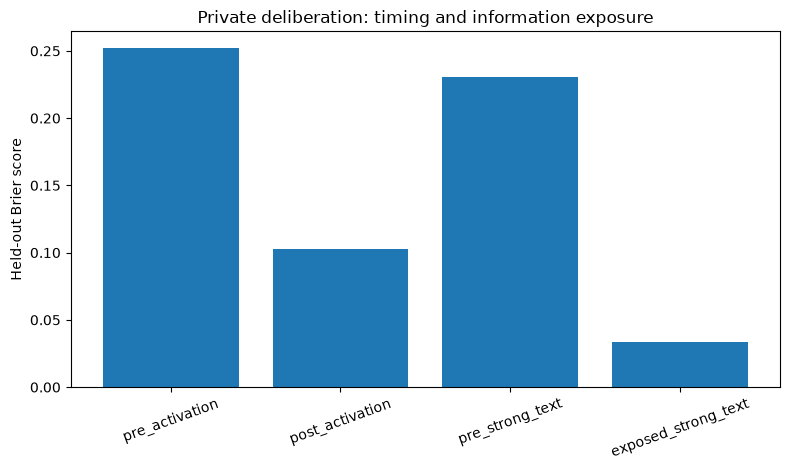

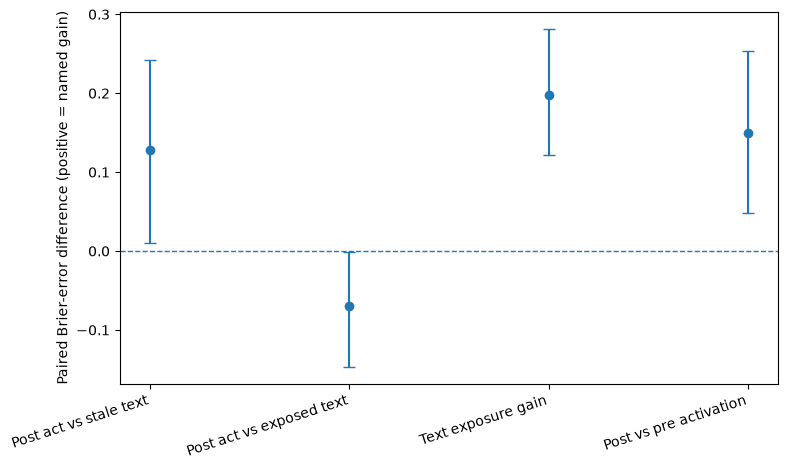

Information-asymmetry pattern supported: True
Archive: /workspace/latent-reservations/22_private_deliberation_information_decomposition_20260816T085830Z.zip


In [12]:
import matplotlib.pyplot as plt
names=["pre_activation","post_activation","pre_strong_text","exposed_strong_text"];fig,ax=plt.subplots(figsize=(8,4.8));ax.bar(names,[metrics[n]["brier"] for n in names]);ax.set_ylabel("Held-out Brier score");ax.set_title("Private deliberation: timing and information exposure");ax.tick_params(axis="x",rotation=20);fig.tight_layout();fig.savefig(FIGURE_DIR/"decomposition_brier.png",dpi=180);plt.show()
fig,ax=plt.subplots(figsize=(8,4.8));labels=["Post act vs stale text","Post act vs exposed text","Text exposure gain","Post vs pre activation"];vals=[boots[c]["observed"] for c in ["private_information_advantage","matched_information_advantage","observer_exposure_gain","activation_timing_gain"]];lo=[boots[c]["ci95_low"] for c in ["private_information_advantage","matched_information_advantage","observer_exposure_gain","activation_timing_gain"]];hi=[boots[c]["ci95_high"] for c in ["private_information_advantage","matched_information_advantage","observer_exposure_gain","activation_timing_gain"]];yerr=np.array([[v-l for v,l in zip(vals,lo)],[h-v for v,h in zip(vals,hi)]]);ax.errorbar(range(len(vals)),vals,yerr=yerr,fmt='o',capsize=4);ax.axhline(0,ls='--',lw=1);ax.set_xticks(range(len(vals)));ax.set_xticklabels(labels,rotation=18,ha='right');ax.set_ylabel("Paired Brier-error difference (positive = named gain)");fig.tight_layout();fig.savefig(FIGURE_DIR/"decomposition_effects.png",dpi=180);plt.show()
summary={"notebook_build":NOTEBOOK_BUILD,"run_id":RUN_ID,"source_run":str(SOURCE_RUN_DIR),"subject_model":SUBJECT_MODEL,"subject_revision_resolved":SUBJECT_REVISION_RESOLVED,"protocol":protocol,"readiness":readiness,"result":result,"claim_boundary":"T1-private is intentionally information-asymmetric and cannot by itself establish privileged neural access. Only T1-matched addresses the matched-information question."};(TABLE_DIR/"result_summary.json").write_text(json.dumps(summary,indent=2));(MANIFEST_DIR/"p3_manifest.json").write_text(json.dumps({"source_run":str(SOURCE_RUN_DIR),"records":str(records_path),"pre_activations":str(ACTIVATION_DIR/"pre_deliberation_t0.safetensors"),"post_activations":str(ACTIVATION_DIR/"post_deliberation_t1.safetensors"),"result":str(TABLE_DIR/"decomposition_result.json")},indent=2));checks=[]
for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file():checks.append({"path":str(p.relative_to(RUN_DIR)),"bytes":p.stat().st_size,"sha256":hashlib.sha256(p.read_bytes()).hexdigest()})
(RUN_DIR/"checksums.json").write_text(json.dumps(checks,indent=2));archive=PROJECT_ROOT/f"22_private_deliberation_information_decomposition_{RUN_ID}.zip"
with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(RUN_DIR.rglob("*")):
        if p.is_file():zf.write(p,arcname=str(Path(NOTEBOOK_SLUG)/RUN_ID/p.relative_to(RUN_DIR)))
print("Information-asymmetry pattern supported:",pattern);print("Archive:",archive)
try:del model;torch.cuda.empty_cache()
except Exception:pass
